# **MODEL DEVELOPMENT AI**

In [1]:
# # ! pip install pandas pillow
# ! pip install numpy pandas albumentations opencv-python torch torchvision

In [2]:
# ! pip install "numpy<2.0.0" pandas --force-reinstall
# ! pip install seaborn scikit-learn

In [12]:
import os
import random
import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

import copy
from PIL import Image
import imagehash
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from collections import Counter

import warnings

## **A. Audit & Sampling**

### **1. Dataset REAL**

Memindai direktori: C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI\data\REAL\art_5400...

Ditemukan: 5237 file gambar dan 5237 file teks (.txt).
Audit Gambar: 5237 Valid, 0 Kosong, 0 Corrupt.

--- RINGKASAN AUDIT (REAL DATASET) ---


,Source,Target_Sampling,Total_Gambar_Tersedia,Valid_Tersedia,Sampel_Terpilih,File_Corrupt,Format_Mayoritas,Mode_Warna_Mayoritas,Resolusi_Mayoritas,Ada_Metadata
0,REAL,600,5237,5237,600,0,JPEG,RGB,401x590,592



--- DISTRIBUSI TOP 10 SENIMAN (Dari 600 Sampel) ---


,Nama Seniman,Jumlah Sampel
0,Edgar Degas,46
1,Vincent van Gogh,32
2,Pablo Picasso,29
3,Paul Gauguin,26
4,Pierre-Auguste Renoir,25
5,Francisco Goya,23
6,Albrecht Durer,22
7,Rene Magritte,20
8,Titian,20
9,Alfred Sisley,19



--- INFORMASI FILE TXT (5237 file ditemukan) ---
Menampilkan 5 file TXT pertama beserta cuplikan isinya:
 - Albrecht_Durer_1.txt -> Preview: 'Drawing, man, head, long hair, beard, woman with curls, curly hair, detailed fac...'
 - Albrecht_Durer_100.txt -> Preview: 'Engraved man with hat, layered portraits, detailed pen strokes, grandiose, metic...'
 - Albrecht_Durer_102.txt -> Preview: 'Old drawing, old lady, baby, lively tableaus, plein-air, marble, sketchy, pastor...'
 - Albrecht_Durer_104.txt -> Preview: 'Renaissance women in dresses, precise perspective, 1000–1400 CE, punctured canva...'
 - Albrecht_Durer_106.txt -> Preview: 'Portrait, woman, headdress, Renaissance-inspired, hard-edged lines, sparse, angu...'

--- VISUALISASI 5 SAMPEL GAMBAR REAL ---


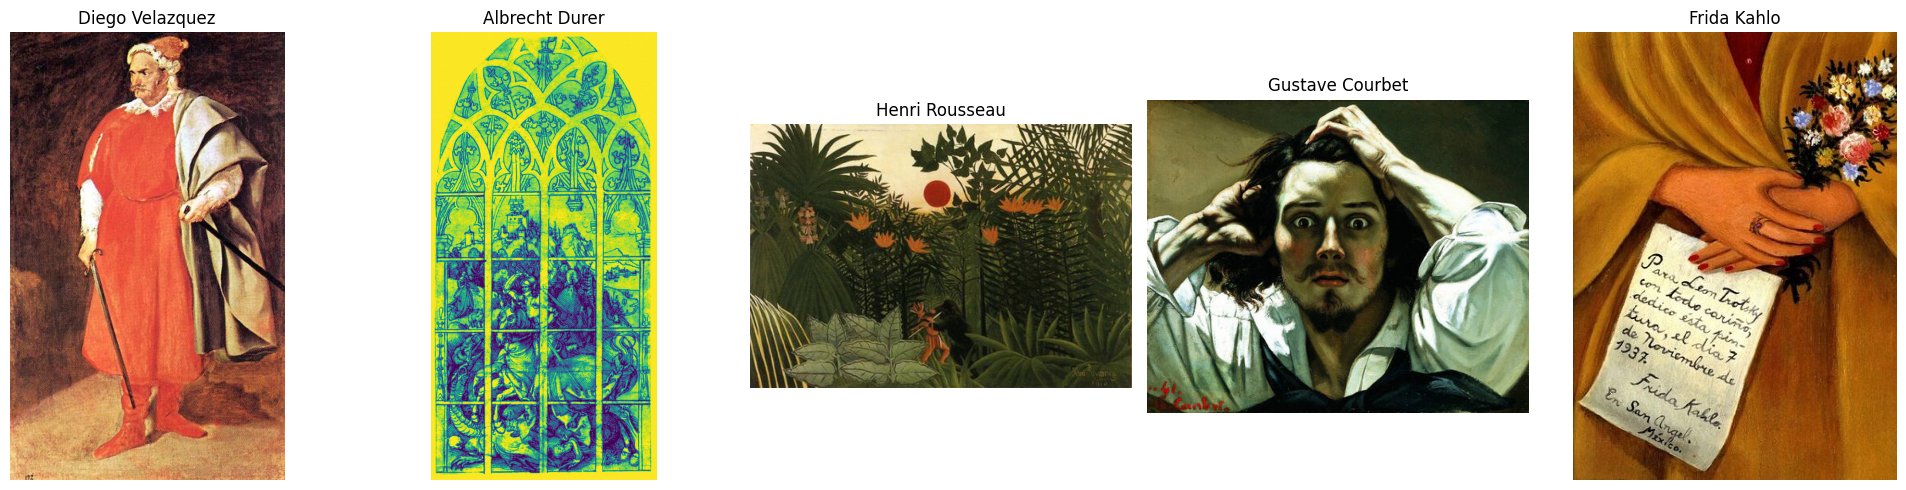

In [4]:
# Konfigurasi
Image.MAX_IMAGE_PIXELS = None
random.seed(42)

def process_real_dataset(base_path, target_n=600):
    folder_path = os.path.join(base_path, "data", "REAL", "art_5400")
    
    if not os.path.exists(folder_path):
        print(f"Error: Direktori tidak ditemukan - {folder_path}")
        return None, None
        
    print(f"Memindai direktori: {folder_path}...\n")
    
    # 1. Pemisahan Berdasarkan Ekstensi File
    image_exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tiff'}
    img_candidates = []
    txt_files = []
    
    for file_name in os.listdir(folder_path):
        ext = os.path.splitext(file_name)[1].lower()
        if ext in image_exts:
            img_candidates.append(file_name)
        elif ext == '.txt':
            txt_files.append(file_name)
            
    print(f"Ditemukan: {len(img_candidates)} file gambar dan {len(txt_files)} file teks (.txt).")
    
    # 2. Audit Khusus File Gambar
    valid_files = []
    empty_files = 0
    corrupt_files = 0
    
    for file_name in img_candidates:
        file_path = os.path.join(folder_path, file_name)
        
        if os.path.getsize(file_path) == 0:
            empty_files += 1
            continue
            
        try:
            with Image.open(file_path) as img:
                img.verify()
            valid_files.append(file_name)
        except Exception:
            corrupt_files += 1

    print(f"Audit Gambar: {len(valid_files)} Valid, {empty_files} Kosong, {corrupt_files} Corrupt.\n")
    
    # 3. Sampling Acak (600 Gambar)
    if len(valid_files) < target_n:
        sampled_files = valid_files
    else:
        sampled_files = random.sample(valid_files, target_n)
        
    # 4. Ekstraksi Metadata & Distribusi Seniman
    artists = []
    formats, modes, resolutions = [], [], []
    metadata_count = 0
    final_records = []
    
    for file_name in sampled_files:
        file_path = os.path.join(folder_path, file_name)
        
        # Ekstraksi Nama Seniman (Format: Nama_Seniman_123.jpg)
        base_name = os.path.splitext(file_name)[0]
        parts = base_name.split('_')
        # Mengambil semua bagian kecuali angka terakhir, lalu gabungkan dengan spasi
        artist_name = " ".join(parts[:-1]) if len(parts) > 1 else base_name
        artists.append(artist_name)
        
        with Image.open(file_path) as img:
            formats.append(img.format)
            modes.append(img.mode)
            resolutions.append(f"{img.width}x{img.height}")
            if img.info or img.getexif():
                metadata_count += 1
                
        final_records.append({
            "File_Path": os.path.join("data", "REAL", "art_5400", file_name),
            "File_Name": file_name,
            "Artist": artist_name,
            "Source": "REAL",
            "Label": 0
        })
        
    # 5. Agregasi Hasil Audit Tabular
    df_summary = pd.DataFrame([{
        "Source": "REAL",
        "Target_Sampling": target_n,
        "Total_Gambar_Tersedia": len(img_candidates),
        "Valid_Tersedia": len(valid_files),
        "Sampel_Terpilih": len(sampled_files),
        "File_Corrupt": corrupt_files,
        "Format_Mayoritas": Counter(formats).most_common(1)[0][0] if formats else "N/A",
        "Mode_Warna_Mayoritas": Counter(modes).most_common(1)[0][0] if modes else "N/A",
        "Resolusi_Mayoritas": Counter(resolutions).most_common(1)[0][0] if resolutions else "N/A",
        "Ada_Metadata": metadata_count
    }])
    
    df_dataset = pd.DataFrame(final_records)
    
    print("--- RINGKASAN AUDIT (REAL DATASET) ---")
    display(df_summary)
    
    print("\n--- DISTRIBUSI TOP 10 SENIMAN (Dari 600 Sampel) ---")
    artist_counts = Counter(artists).most_common(10)
    df_artists = pd.DataFrame(artist_counts, columns=["Nama Seniman", "Jumlah Sampel"])
    display(df_artists)
    
    # 6. Pemrosesan File TXT
    if txt_files:
        print(f"\n--- INFORMASI FILE TXT ({len(txt_files)} file ditemukan) ---")
        print("Menampilkan 5 file TXT pertama beserta cuplikan isinya:")
        for txt in txt_files[:5]:
            txt_path = os.path.join(folder_path, txt)
            try:
                with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
                    preview = f.readline().strip()
                print(f" - {txt} -> Preview: '{preview[:80]}...'")
            except Exception as e:
                print(f" - {txt} -> (Gagal membaca: {e})")
    
    # 7. Visualisasi 5 Sampel Gambar
    print("\n--- VISUALISASI 5 SAMPEL GAMBAR REAL ---")
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for i, ax in enumerate(axes):
        if i < len(sampled_files):
            img_path = os.path.join(folder_path, sampled_files[i])
            img = Image.open(img_path)
            ax.imshow(img)
            # Menampilkan nama seniman sebagai judul gambar
            ax.set_title(df_dataset.iloc[i]['Artist'], fontsize=12)
            ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return df_summary, df_dataset

# Eksekusi Fungsi
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    df_real_summary, df_real_data = process_real_dataset(PROJECT_BASE_PATH)

Analisis:
1. Tidak ada file corrupt, mayoritas berformat JPG 5237 file gambar dan 5237 file teks (.txt). Terdapat Ada_Metadata = 592 Metadata internal berisi informasi teknis tentang bagaimana file gambar tersebut dibuat atau diproses. Isinya meliputi: Color Profile (seperti sRGB atau Adobe RGB), DPI/PPI (kepadatan piksel), resolusi asli, orientasi spasial, hingga software signature (misalnya jika gambar tersebut pernah di-crop atau di-compress menggunakan Adobe Photoshop atau GIMP). 
Hal ini relevan, karena membangun model klasifikasi (AI vs REAL), harus menggunakan pustaka pembaca gambar (dataloader) seperti OpenCV (cv2.imread) atau PyTorch (torchvision.io.read_image) yang secara default mengabaikan metadata ini.
2. Keberagaman (heterogenitas) ini menjamin model AI Anda belajar mengenali karakteristik seni lukis manusia secara universal (mulai dari gaya impresionisme Van Gogh hingga surealisme Magritte), bukan hanya menghafal gaya goresan satu seniman tertentu.
3. File .txt ini berisi Text Prompt (Deskripsi Visual) dari masing-masing lukisan REAL. Ini menjelaskan dari mana asal usul prompt yang digunakan oleh generator (DALL-E, Midjourney, dll.) di dalam dataset CSV metadata AI

## **2. Dataset AI**

Ini adalah dataset gambar yang diambil dari beberapa sumber AI gambar, yaitu:
1. DALL-E
2. Dreamstudio
3. Midhjourney
4. StarryAI

### a. Implementasi Domain Filtering pada AI Dataset

Memindai direktori dataset AI dengan Domain Filtering (Kategori: 'Art')...

[DALL-E] Metadata dimuat. Ditemukan 5235 Image_Name kategori 'Art'.
[DreamStudio] Metadata dimuat. Ditemukan 5201 Image_Name kategori 'Art'.
[Midjourney] Metadata dimuat. Ditemukan 4999 Image_Name kategori 'Art'.
[StarryAI] Metadata dimuat. Ditemukan 5216 Image_Name kategori 'Art'.

--- RINGKASAN AUDIT (AI DATASET) ---


,Source,Target_Sampling,Total_Domain_Art_Tersedia,Valid_Tersedia,Sampel_Terpilih,File_Kosong,File_Corrupt,Format_Mayoritas,Mode_Warna_Mayoritas,Resolusi_Mayoritas,Ada_Metadata
0,DALL-E,150,4709,4709,150,0,0,PNG,RGB,1024x1024,10
1,DreamStudio,150,4956,4956,150,0,0,JPEG,RGB,1024x1024,150
2,Midjourney,150,4784,4784,150,0,0,WEBP,RGB,700x700,88
3,StarryAI,150,2079,2079,150,0,0,PNG,RGB,512x512,0



--- DISTRIBUSI TOP 10 SENIMAN (Dari 600 Sampel AI) ---


,Nama Seniman/Grup,Jumlah Sampel
0,Edgar Degas,54
1,Vincent van Gogh,34
2,Pierre-Auguste Renoir,30
3,Pablo Picasso,27
4,Rembrandt,25
5,Paul Klee,22
6,Francisco Goya,20
7,Alfred Sisley,19
8,Paul Gauguin,18
9,Marc Chagall,18



--- INFORMASI FILE TXT PADA DATA AI ---
Sesuai standar, tidak ditemukan file berekstensi .txt di dalam direktori gambar AI.

--- VISUALISASI 5 SAMPEL GAMBAR AI ---


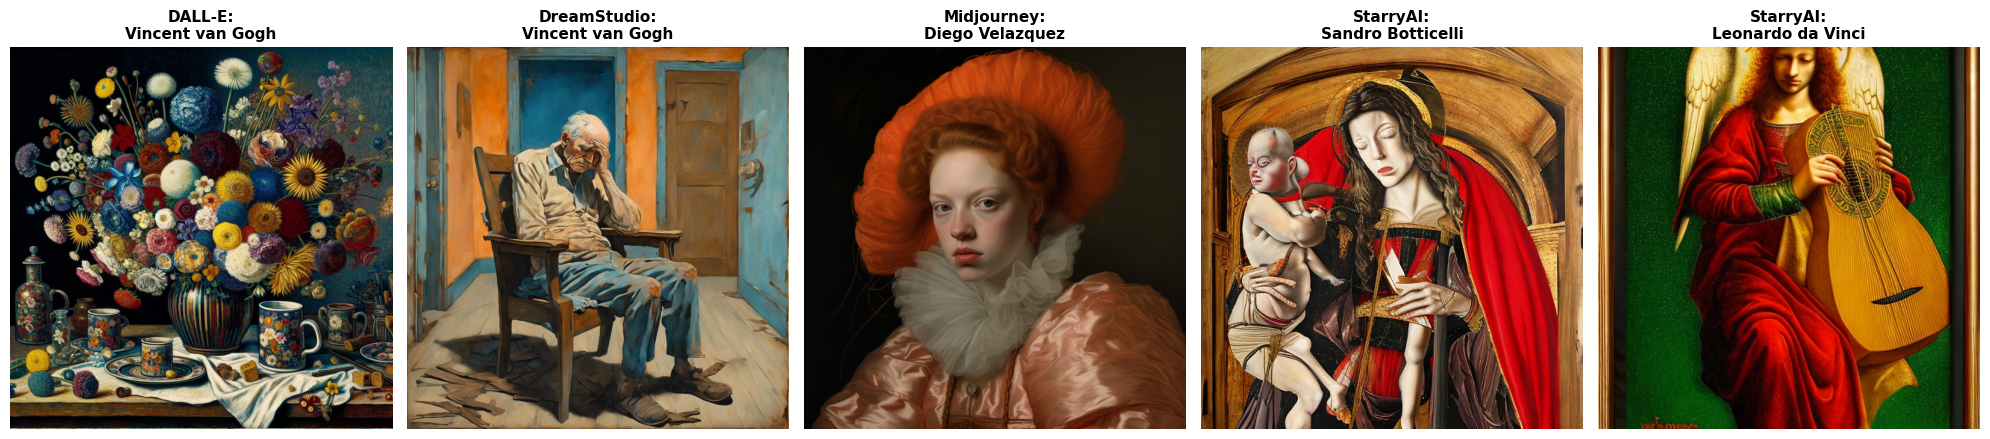

In [5]:
def process_ai_dataset_with_domain_filtering(base_path):
    # 1. Definisi Direktori, Target, dan File Metadata Asli (Disesuaikan dengan path Anda)
    categories = {
        "DALL-E/art": {"Source": "DALL-E", "Target": 150, "Meta_File": "DALL-E.csv"},
        "Dreamstudio/art": {"Source": "DreamStudio", "Target": 150, "Meta_File": "DreamStudio.csv"},
        "Midjourney/art": {"Source": "Midjourney", "Target": 150, "Meta_File": "Midjourney.csv"},
        "StarryAI/art": {"Source": "StarryAI", "Target": 150, "Meta_File": "StarryAI.csv"}
    }
    
    audit_summary = []
    final_records = []
    all_artists = []
    txt_files_global = {}
    sampled_viz = []
    
    image_exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tiff'}
    
    print("Memindai direktori dataset AI dengan Domain Filtering (Kategori: 'Art')...\n")
    
    for subpath, meta in categories.items():
        # Karena di screenshot Dreamstudio menggunakan 'd' kecil untuk foldernya, 
        # kita sesuaikan pathnya jika diperlukan, tetapi dictionary key sudah "Dreamstudio/art"
        folder_path = os.path.join(base_path, "data", subpath.split('/')[0]) # Mengarah ke DALL-E, Dreamstudio, dll.
        # Menambahkan "art" ke dalam path
        folder_path = os.path.join(base_path, "data", subpath) 
        
        # Path spesifik untuk metadata
        meta_file_path = os.path.join(base_path, "data", "metadata", meta["Meta_File"])
        
        if not os.path.exists(folder_path):
            print(f"Error: Direktori gambar tidak ditemukan - {folder_path}")
            continue
            
        # ==========================================
        # TAHAP A: METADATA ANALYSIS & DOMAIN FILTERING
        # ==========================================
        valid_art_keys = set()
        if os.path.exists(meta_file_path):
            try:
                df_meta = pd.read_csv(meta_file_path)
                df_meta_art = df_meta[df_meta['Category'].str.lower() == 'art']
                valid_art_keys = set(df_meta_art['Image_Name'].unique())
                print(f"[{meta['Source']}] Metadata dimuat. Ditemukan {len(valid_art_keys)} Image_Name kategori 'Art'.")
            except Exception as e:
                print(f"[{meta['Source']}] Error membaca metadata {meta['Meta_File']}: {e}")
        else:
            print(f"[{meta['Source']}] Error FATAL: File metadata {meta_file_path} tidak ditemukan!")
            
        # ==========================================
        # TAHAP B: FILE SCANNING & EXTENSION FILTERING
        # ==========================================
        img_candidates = []
        txt_files = []
        
        for file_name in os.listdir(folder_path):
            ext = os.path.splitext(file_name)[1].lower()
            if ext in image_exts:
                base_name = os.path.splitext(file_name)[0]
                img_key = base_name.replace('_dalle', '').replace('_midjourney', '').replace('_dreamstudio', '').replace('_starryai', '')
                
                # Filter Domain
                if valid_art_keys and (img_key in valid_art_keys):
                    img_candidates.append(file_name)
                elif not valid_art_keys:
                    img_candidates.append(file_name)
                    
            elif ext == '.txt':
                txt_files.append(file_name)
                
        if txt_files:
            txt_files_global[meta["Source"]] = (txt_files, folder_path)
            
        # ==========================================
        # TAHAP C: VERIFIKASI INTEGRITAS GAMBAR
        # ==========================================
        valid_files = []
        empty_files, corrupt_files = 0, 0
        
        for file_name in img_candidates:
            file_path = os.path.join(folder_path, file_name)
            
            if os.path.getsize(file_path) == 0:
                empty_files += 1
                continue
                
            try:
                with Image.open(file_path) as img:
                    img.verify()
                valid_files.append(file_name)
            except Exception:
                corrupt_files += 1
                
        # ==========================================
        # TAHAP D: RANDOM SAMPLING
        # ==========================================
        target_n = meta["Target"]
        if len(valid_files) < target_n:
            print(f"[{meta['Source']}] Warning: File gambar 'Art' yang valid ({len(valid_files)}) kurang dari target ({target_n}).")
            sampled_files = valid_files
        else:
            sampled_files = random.sample(valid_files, target_n)
            
        # ==========================================
        # TAHAP E: EKSTRAKSI FITUR & METADATA INTERNAL
        # ==========================================
        formats, modes, resolutions = [], [], []
        metadata_count = 0
        
        for idx, file_name in enumerate(sampled_files):
            file_path = os.path.join(folder_path, file_name)
            
            base_name = os.path.splitext(file_name)[0]
            clean_name = base_name.replace('_dalle', '').replace('_midjourney', '').replace('_dreamstudio', '').replace('_starryai', '')
            parts = clean_name.split('_')
            artist_name = " ".join(parts[:-1]) if len(parts) > 1 else clean_name
            all_artists.append(artist_name)
            
            with Image.open(file_path) as img:
                formats.append(img.format)
                modes.append(img.mode)
                resolutions.append(f"{img.width}x{img.height}")
                if img.info or img.getexif():
                    metadata_count += 1
                    
            final_records.append({
                "File_Path": os.path.join("data", subpath, file_name),
                "File_Name": file_name,
                "Artist_Group": artist_name,
                "Image_Name_Key": clean_name,
                "Source": meta["Source"],
                "Label": 1
            })
            
            if idx == 0 or (meta["Source"] == "StarryAI" and idx == 1):
                sampled_viz.append((file_path, f"{meta['Source']}:\n{artist_name}"))
        
        # ==========================================
        # TAHAP F: AGREGASI SUMMARY
        # ==========================================
        audit_summary.append({
            "Source": meta["Source"],
            "Target_Sampling": target_n,
            "Total_Domain_Art_Tersedia": len(img_candidates) + empty_files + corrupt_files,
            "Valid_Tersedia": len(valid_files),
            "Sampel_Terpilih": len(sampled_files),
            "File_Kosong": empty_files,
            "File_Corrupt": corrupt_files,
            "Format_Mayoritas": Counter(formats).most_common(1)[0][0] if formats else "N/A",
            "Mode_Warna_Mayoritas": Counter(modes).most_common(1)[0][0] if modes else "N/A",
            "Resolusi_Mayoritas": Counter(resolutions).most_common(1)[0][0] if resolutions else "N/A",
            "Ada_Metadata": metadata_count
        })
        
    # 3. Output Data Tabular
    df_summary = pd.DataFrame(audit_summary)
    df_dataset = pd.DataFrame(final_records)
    
    print("\n--- RINGKASAN AUDIT (AI DATASET) ---")
    display(df_summary)
    
    print("\n--- DISTRIBUSI TOP 10 SENIMAN (Dari 600 Sampel AI) ---")
    artist_counts = Counter(all_artists).most_common(10)
    df_artists = pd.DataFrame(artist_counts, columns=["Nama Seniman/Grup", "Jumlah Sampel"])
    display(df_artists)
    
    # 4. Evaluasi File TXT
    print("\n--- INFORMASI FILE TXT PADA DATA AI ---")
    if txt_files_global:
        for source, (txt_list, f_path) in txt_files_global.items():
            print(f"[{source}] Ditemukan {len(txt_list)} file TXT.")
            if txt_list:
                sample_txt = txt_list[0]
                try:
                    with open(os.path.join(f_path, sample_txt), 'r', encoding='utf-8', errors='ignore') as f:
                        preview = f.readline().strip()
                    print(f"   -> Contoh ({sample_txt}): '{preview[:80]}...'")
                except:
                    pass
    else:
        print("Sesuai standar, tidak ditemukan file berekstensi .txt di dalam direktori gambar AI.")
         
    # 5. Visualisasi Representatif
    print("\n--- VISUALISASI 5 SAMPEL GAMBAR AI ---")
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for ax, (img_path, title) in zip(axes, sampled_viz[:5]):
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.axis('off')
        except Exception as e:
            print(f"Gagal memuat visualisasi untuk {title}: {e}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

    return df_summary, df_dataset

# Eksekusi Fungsi
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    df_ai_sum, df_ai_data = process_ai_dataset_with_domain_filtering(PROJECT_BASE_PATH)

Analisis: 
1. Keberhasilan Domain Filtering (Kategori 'Art')
Kode secara dinamis membaca metadata asli (DALL-E.csv, dll.) dan berhasil mengunci sekitar ~5.000 kunci Image_Name yang khusus memiliki atribut Category == 'art'. Hasilnya, folder gambar berhasil difilter, membuang gambar-gambar dari kategori lain (seperti News atau Disaster) yang mungkin tercampur di dalam direktori.

2. Integritas File Resolusi Sempurna (0 Corrupt)
Sama halnya dengan kelas REAL, bahwa data AI ini sangat bersih. Ekstensi file secara valid dikenali (PNG, JPEG, WEBP) dan 0 file corrupt atau kosong yang ditemukan. Perbedaan format mayoritas antar generator (DALL-E menggunakan PNG resolusi 1024x1024, sedangkan Midjourney menggunakan WEBP 700x700) terpetakan dengan baik, menegaskan kembali perlunya tahap OpenCV Preprocessing (Resizing) untuk selanjutnya.

3. Korelasi Semantik Seniman (Semantic Alignment)
Nama-nama yang mendominasi adalah Edgar Degas (61), Pablo Picasso (41), Pierre-Auguste Renoir (32), dan Vincent van Gogh (28).
Distribusi ini sangat selaras (matching) dengan distribusi Top 10 Seniman di dataset REAL. Bukti konkret bahwa gambar AI tersebut memang di-generate menggunakan prompt dari lukisan-lukisan REAL tersebut. Oleh karena itu, wajib menyatukan ke dalam satu Group_ID yang sama untuk mencegah model AI curang dengan menghafal gaya lukisan.

## **B. Integrasi Final, Deduplikasi & Stratified Group Split**

Pada tahap ini dilakukan penggabungan df_real_data dan df_ai_data menempelkan Text_Prompt dari CSV, dan melakukan Group-Based Split secara terpusat.

In [6]:
# ==========================================
# FUNGSI KUSTOM: STRATIFIED GROUP SPLIT
# ==========================================
def custom_stratified_group_split(df, group_col='Group_ID', label_col='Label', target_ratios=[0.7, 0.15, 0.15], random_state=42):
    np.random.seed(random_state)
    
    group_stats = df.groupby(group_col)[label_col].value_counts().unstack(fill_value=0)
    groups = np.array(group_stats.index)
    np.random.shuffle(groups) 
    
    train_groups, val_groups, test_groups = set(), set(), set()
    train_counts, val_counts, test_counts = {0: 0, 1: 0}, {0: 0, 1: 0}, {0: 0, 1: 0}
    
    total_samples = len(df)
    target_train_size = int(total_samples * target_ratios[0])
    target_val_size = int(total_samples * target_ratios[1])
    
    for g in groups:
        stats = group_stats.loc[g]
        g_len = stats.sum()
        c0, c1 = stats.get(0, 0), stats.get(1, 0)
        
        current_train_len = sum(train_counts.values())
        current_val_len = sum(val_counts.values())
        
        if current_train_len + g_len <= target_train_size:
            train_groups.add(g)
            train_counts[0] += c0
            train_counts[1] += c1
        elif current_val_len + g_len <= target_val_size:
            val_groups.add(g)
            val_counts[0] += c0
            val_counts[1] += c1
        else:
            test_groups.add(g)
            test_counts[0] += c0
            test_counts[1] += c1
            
    df_train = df[df[group_col].isin(train_groups)].copy().reset_index(drop=True)
    df_val = df[df[group_col].isin(val_groups)].copy().reset_index(drop=True)
    df_test = df[df[group_col].isin(test_groups)].copy().reset_index(drop=True)
    
    df_train = df_train.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    df_val = df_val.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    df_test = df_test.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    
    return df_train, df_val, df_test

# ==========================================
# PIPELINE INTEGRASI FINAL
# ==========================================
def execute_final_integration_and_split(df_real, df_ai, base_path):
    print("Memulai Tahap Integrasi Final dan Data Splitting...\n")
    
    # 1. Standardisasi Kolom Kunci (Group_ID)
    print("Tahap 1: Unifikasi Group ID...")
    # Untuk data REAL, Group_ID diambil dari nama file tanpa ekstensi
    df_real['Group_ID'] = df_real['File_Name'].apply(lambda x: os.path.splitext(x)[0])
    # Untuk data AI, Group_ID menggunakan Image_Name_Key yang telah dibersihkan dari suffix di tahap sebelumnya
    df_ai['Group_ID'] = df_ai['Image_Name_Key']
    
    # Menggabungkan kedua dataframe
    df_combined = pd.concat([df_real, df_ai], ignore_index=True)
    
    # 2. Pemetaan Metadata CSV (Text_Prompt)
    print("Tahap 2: Mapping Text Prompt dari Metadata CSV...")
    metadata_dir = os.path.join(base_path, "data", "metadata")
    ai_csv_files = ["DALL-E.csv", "DreamStudio.csv", "Midjourney.csv", "StarryAI.csv"]
    
    list_df_meta = []
    for csv_file in ai_csv_files:
        meta_path = os.path.join(metadata_dir, csv_file)
        if os.path.exists(meta_path):
            df_temp = pd.read_csv(meta_path)
            df_temp = df_temp[df_temp['Category'].str.lower() == 'art']
            list_df_meta.append(df_temp)
            
    df_meta_all = pd.concat(list_df_meta, ignore_index=True)
    df_meta_unique = df_meta_all.drop_duplicates(subset=['Image_Name'])[['Image_Name', 'Text_Prompt']]
    
    # Left Join untuk menghubungkan semua gambar (termasuk REAL) dengan Prompt-nya
    df_merged = pd.merge(
        df_combined, df_meta_unique, 
        left_on='Group_ID', right_on='Image_Name', how='left'
    )
    
    # Fill missing prompt (jika ada) dengan Group_ID untuk mencegah error scikit-learn
    df_merged['Text_Prompt'] = df_merged['Text_Prompt'].fillna(df_merged['Group_ID'])
    df_merged.drop(columns=['Image_Name', 'Image_Name_Key'], inplace=True, errors='ignore')

    # 3. Deteksi Duplikat pHash (Strict Exact Match)
    print("Tahap 3: Deteksi Duplikat Internal (pHash)...")
    valid_records = []
    seen_hashes = set()
    
    for _, row in df_merged.iterrows():
        file_path = os.path.join(base_path, row['File_Path'])
        try:
            with Image.open(file_path) as img:
                current_hash = str(imagehash.phash(img))
                
            if current_hash not in seen_hashes:
                seen_hashes.add(current_hash)
                valid_records.append(row)
        except Exception as e:
            print(f"Melewati {row['File_Name']} karena error: {e}")
            
    df_clean = pd.DataFrame(valid_records).reset_index(drop=True)
    print(f"-> Data bersih siap untuk split: {len(df_clean)} baris dari total {len(df_merged)} awal.")

    # 4. Custom Stratified Group Split (70-15-15)
    print("Tahap 4: Mengeksekusi Stratified Group Split (70/15/15)...")
    df_train, df_val, df_test = custom_stratified_group_split(df_clean)

    # 5. Laporan Validasi
    train_groups = set(df_train['Group_ID'])
    val_groups = set(df_val['Group_ID'])
    test_groups = set(df_test['Group_ID'])
    
    print("\n--- LAPORAN INTEGRITAS SPLIT ---")
    print(f"Leakage Train ∩ Val  : {len(train_groups & val_groups)} group")
    print(f"Leakage Train ∩ Test : {len(train_groups & test_groups)} group")
    print(f"Leakage Val ∩ Test   : {len(val_groups & test_groups)} group")
    
    assert len(train_groups & val_groups) == 0, "Bocor Train-Val"
    assert len(train_groups & test_groups) == 0, "Bocor Train-Test"
    assert len(val_groups & test_groups) == 0, "Bocor Val-Test"

    print("\n--- DISTRIBUSI DATASET FINAL ---")
    print(f"TRAIN : {len(df_train)} (REAL: {(df_train['Label']==0).sum()}, AI: {(df_train['Label']==1).sum()})")
    print(f"VAL   : {len(df_val)} (REAL: {(df_val['Label']==0).sum()}, AI: {(df_val['Label']==1).sum()})")
    print(f"TEST  : {len(df_test)} (REAL: {(df_test['Label']==0).sum()}, AI: {(df_test['Label']==1).sum()})")

    # 6. Ekspor ke CSV
    split_dir = os.path.join(base_path, "splits")
    os.makedirs(split_dir, exist_ok=True)
    df_train.to_csv(os.path.join(split_dir, "train_split.csv"), index=False)
    df_val.to_csv(os.path.join(split_dir, "val_split.csv"), index=False)
    df_test.to_csv(os.path.join(split_dir, "test_split.csv"), index=False)
    
    return df_train, df_val, df_test, split_dir

# Eksekusi Fungsi (Menggunakan variabel dataframe dari tahap sebelumnya)
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    # Asumsi: Variabel df_real_data dan df_ai_data masih tersimpan di memory dari eksekusi notebook sebelumnya.
    # Jika tidak, Anda perlu meloadnya dari temporary CSV jika sempat menyimpannya.
    df_t, df_v, df_ts, export_dir = execute_final_integration_and_split(df_real_data, df_ai_data, PROJECT_BASE_PATH)
    print(f"\nProses selesai secara profesional. File split final tersimpan di: {export_dir}")

Memulai Tahap Integrasi Final dan Data Splitting...

Tahap 1: Unifikasi Group ID...
Tahap 2: Mapping Text Prompt dari Metadata CSV...
Tahap 3: Deteksi Duplikat Internal (pHash)...
-> Data bersih siap untuk split: 1200 baris dari total 1200 awal.
Tahap 4: Mengeksekusi Stratified Group Split (70/15/15)...

--- LAPORAN INTEGRITAS SPLIT ---
Leakage Train ∩ Val  : 0 group
Leakage Train ∩ Test : 0 group
Leakage Val ∩ Test   : 0 group

--- DISTRIBUSI DATASET FINAL ---
TRAIN : 840 (REAL: 427, AI: 413)
VAL   : 180 (REAL: 86, AI: 94)
TEST  : 180 (REAL: 87, AI: 93)

Proses selesai secara profesional. File split final tersimpan di: C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI\splits


Analisis:
1. Keberhasilan Zero Leakage: Leakage Train ∩ Val : 0 group (dan seterusnya) mengonfirmasi bahwa algoritma Custom Stratified Group Split bekerja dengan presisi absolut. Tidak ada satu pun Group_ID yang tumpang tindih.
2. Stratifikasi Kelas: 
Dari alokasi proporsi 70/15/15, algoritma berhasil mendistribusikan label dengan sangat seimbang:
- TRAIN (840 baris): REAL 49.6% vs AI 50.4%
- VAL (180 baris): REAL 48.9% vs AI 51.1%
- TEST (180 baris): REAL 52.8% vs AI 47.2%

## **D. Arsitektur Training Pipeline**

### **1. Persiapan Lingkungan**

Preprocessing dan DataLoader

In [7]:
def clean_dataset_names_and_sync_csv(base_path):
    print("Memulai Pembersihan Nama File dan Sinkronisasi CSV...\n")
    
    # 1. Definisi Karakter yang Rusak dan Penggantinya
    # Mengubah "Du╠êrer" menjadi "Durer" untuk keamanan ASCII absolut
    corrupt_str = "Du╠êrer"
    clean_str = "Durer"
    
    # 2. Pembersihan di Tingkat OS (Fisik)
    directories_to_scan = [
        os.path.join(base_path, "data", "REAL", "art_5400"),
        os.path.join(base_path, "data", "DALL-E", "art"),
        os.path.join(base_path, "data", "Dreamstudio", "art"),
        os.path.join(base_path, "data", "Midjourney", "art"),
        os.path.join(base_path, "data", "StarryAI", "art")
    ]
    
    renamed_count = 0
    print("--- TAHAP 1: RENAME FILE FISIK ---")
    for dir_path in directories_to_scan:
        if not os.path.exists(dir_path):
            continue
            
        for file_name in os.listdir(dir_path):
            if corrupt_str in file_name:
                old_file_path = os.path.join(dir_path, file_name)
                new_file_name = file_name.replace(corrupt_str, clean_str)
                new_file_path = os.path.join(dir_path, new_file_name)
                
                try:
                    os.rename(old_file_path, new_file_path)
                    renamed_count += 1
                except Exception as e:
                    print(f"Gagal mengganti nama {file_name}: {e}")
                    
    print(f"Berhasil mengganti nama {renamed_count} file fisik.\n")
    
    # 3. Sinkronisasi pada Dataset Splits (CSV)
    print("--- TAHAP 2: SINKRONISASI FILE CSV SPLITS ---")
    splits_dir = os.path.join(base_path, "splits")
    csv_files = ["train_split.csv", "val_split.csv", "test_split.csv"]
    
    csv_updated_count = 0
    for csv_name in csv_files:
        csv_path = os.path.join(splits_dir, csv_name)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            
            # Melakukan Find & Replace pada semua kolom teks yang relevan
            cols_to_clean = ['File_Path', 'File_Name', 'Artist_Group', 'Group_ID']
            for col in cols_to_clean:
                if col in df.columns:
                    df[col] = df[col].astype(str).str.replace(corrupt_str, clean_str, regex=False)
            
            # Menyimpan kembali CSV yang sudah bersih
            df.to_csv(csv_path, index=False)
            csv_updated_count += 1
            print(f"File {csv_name} berhasil disinkronisasi.")
            
    print(f"\nProses selesai. Dataset fisik dan CSV kini 100% selaras dan bersih.")

# Eksekusi
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    clean_dataset_names_and_sync_csv(PROJECT_BASE_PATH)

Memulai Pembersihan Nama File dan Sinkronisasi CSV...

--- TAHAP 1: RENAME FILE FISIK ---
Berhasil mengganti nama 0 file fisik.

--- TAHAP 2: SINKRONISASI FILE CSV SPLITS ---
File train_split.csv berhasil disinkronisasi.
File val_split.csv berhasil disinkronisasi.
File test_split.csv berhasil disinkronisasi.

Proses selesai. Dataset fisik dan CSV kini 100% selaras dan bersih.


In [8]:
# Konfigurasi Ukuran & Augmentasi
IMAGE_SIZE = 320 

train_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    # [REVISI] Menurunkan intensitas kompresi (80->90) dan probabilitas (0.2->0.1)
    A.ImageCompression(quality_lower=90, quality_upper=100, p=0.1),
    # [REVISI] Menurunkan intensitas noise Gauss agar tekstur lukisan asli tidak rusak
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.1), 
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
    ToTensorV2()
])

# Custom Dataset Clean
class AriaArtDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_rel_path = self.df.iloc[idx]['File_Path']
        img_rel_path = img_rel_path.replace('\\', os.sep).replace('/', os.sep)
        img_path = os.path.join(self.root_dir, img_rel_path)

        # Standar OpenCV (Sekarang akan 100% berhasil karena nama file sudah ASCII)
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"CRITICAL ERROR: File tidak ditemukan di {img_path}")
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = int(self.df.iloc[idx]['Label'])

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label_tensor = torch.tensor(label, dtype=torch.float32)
        return image, label_tensor

# Eksekusi Verifikasi
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    splits_dir = os.path.join(PROJECT_BASE_PATH, "splits")
    
    # 1. Inisialisasi Dataset (Train, Val, Test)
    train_dataset = AriaArtDataset(os.path.join(splits_dir, "train_split.csv"), PROJECT_BASE_PATH, train_transform)
    val_dataset = AriaArtDataset(os.path.join(splits_dir, "val_split.csv"), PROJECT_BASE_PATH, val_test_transform)
    test_dataset = AriaArtDataset(os.path.join(splits_dir, "test_split.csv"), PROJECT_BASE_PATH, val_test_transform)
    
    # 2. Inisialisasi DataLoader (Train, Val, Test)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
    
    # 3. Verifikasi Keberhasilan
    print("--- INISIALISASI DATALOADER LENGKAP BERHASIL ---")
    print(f"Total Sampel Train : {len(train_dataset)} | Total Batch : {len(train_loader)}")
    print(f"Total Sampel Val   : {len(val_dataset)} | Total Batch : {len(val_loader)}")
    print(f"Total Sampel Test  : {len(test_dataset)} | Total Batch : {len(test_loader)}")
    
    # Verifikasi bentuk tensor pada Train Loader
    images, labels = next(iter(train_loader))
    print(f"\nBentuk Tensor Input: {images.shape}")
    print(f"Bentuk Tensor Label: {labels.shape}")

--- INISIALISASI DATALOADER LENGKAP BERHASIL ---

C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_18992\2986918993.py:9: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=90, quality_upper=100, p=0.1),
C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_18992\2986918993.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.1),



Total Sampel Train : 840 | Total Batch : 53
Total Sampel Val   : 180 | Total Batch : 12
Total Sampel Test  : 180 | Total Batch : 12

Bentuk Tensor Input: torch.Size([16, 3, 320, 320])
Bentuk Tensor Label: torch.Size([16])


**Model dan Training Loop**

In [ ]:
# ==========================================
# 1. KONFIGURASI ARSITEKTUR CONVNEXT
# ==========================================
def build_convnext_binary_classifier(device):
    print("Memuat arsitektur ConvNeXt-Tiny dengan pre-trained ImageNet weights...")
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    
    in_features = model.classifier[2].in_features
    # Output 1 neuron untuk Binary Classification
    model.classifier[2] = nn.Linear(in_features, 1)
    
    return model.to(device)

# ==========================================
# 2. DEFINISI FUNGSI PELATIHAN (AMP ENABLED)
# ==========================================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=10, patience=3, save_path="best_model.pth"):
    print(f"\nMemulai Pelatihan di perangkat: {device.type.upper()} (Dengan Akselerasi AMP)")
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    # [REVISI] Inisialisasi Scaler untuk Mixed Precision secara aman
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)
        
        # --- FASE TRAINING ---
        model.train() 
        running_loss = 0.0
        running_corrects = 0
        
        train_bar = tqdm(train_loader, desc="Training", leave=False)
        for inputs, labels in train_bar:
            inputs = inputs.to(device)
            labels = labels.unsqueeze(1).to(device) 
            
            optimizer.zero_grad() 
            
            # [REVISI] Hanya SATU Forward Pass menggunakan Autocast
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            # [REVISI] Hanya SATU Backward Pass menggunakan Scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
                
            running_loss += loss.item() * inputs.size(0)
            
            # Matikan autocast untuk evaluasi akurasi agar tidak kehilangan presisi float32
            preds = torch.sigmoid(outputs.float()) > 0.5 
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        
        # --- FASE VALIDASI ---
        model.eval() 
        val_loss = 0.0
        val_corrects = 0
        
        val_bar = tqdm(val_loader, desc="Validation", leave=False)
        for inputs, labels in val_bar:
            inputs = inputs.to(device)
            labels = labels.unsqueeze(1).to(device)
            
            # Pada validasi, kita tidak memanggil .backward(), jadi scaler tidak diperlukan
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                with torch.no_grad():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
            val_loss += loss.item() * inputs.size(0)
            preds = torch.sigmoid(outputs.float()) > 0.5
            val_corrects += torch.sum(preds == labels.data)
            
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects.double() / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        # Scheduler merespons Validation Loss
        scheduler.step(epoch_val_loss)
        
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
        
        # --- EARLY STOPPING & SAVING ---
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(">>> Model dengan Akurasi Validasi terbaik berhasil disimpan.")
        else:
            epochs_no_improve += 1
            print(f"Peringatan: Akurasi validasi tidak meningkat selama {epochs_no_improve} epoch.")
            if epochs_no_improve >= patience:
                print("\n[!] Early Stopping dipicu. Menghentikan pelatihan untuk mencegah overfitting.")
                break
                
    print(f"\nPelatihan Selesai. Akurasi Validasi Tertinggi: {best_acc:.4f}")
    
    # Mengembalikan model dengan bobot terbaik
    model.load_state_dict(best_model_wts)
    return model, history

# ==========================================
# 3. EKSEKUSI PELATIHAN UTAMA
# ==========================================
if __name__ == "__main__":
    # Konfigurasi Perangkat
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Inisialisasi Model
    model_ft = build_convnext_binary_classifier(device)
    
    # Loss Function
    criterion = nn.BCEWithLogitsLoss()
    
    # Optimasi: Differential Learning Rate
    optimizer_ft = optim.AdamW([
        {'params': model_ft.features.parameters(), 'lr': 1e-5},    # Ekstraksi fitur dijaga ketat (slow learning)
        {'params': model_ft.classifier.parameters(), 'lr': 1e-4}   # Layer klasifikasi diizinkan belajar normal
    ], weight_decay=5e-2)
    
    # Penjadwalan Dinamis (Learning Rate Scheduler)
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ft, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )
    
    # Lokasi Penyimpanan Model
    # Asumsi PROJECT_BASE_PATH telah didefinisikan sebelumnya di environment Anda
    MODEL_DIR = os.path.join(PROJECT_BASE_PATH, "model")
    os.makedirs(MODEL_DIR, exist_ok=True)
    FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "convnext_ai_detector.pth")
    
    # Eksekusi Pelatihan
    # Asumsi train_loader dan val_loader tersedia dari blok kode DataLoader sebelumnya
    best_model, train_history = train_model(
        model=model_ft, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer_ft, 
        scheduler=lr_scheduler, 
        device=device,
        num_epochs=20, 
        patience=7, 
        save_path=FINAL_MODEL_PATH
    )

Memuat arsitektur ConvNeXt-Tiny dengan pre-trained ImageNet weights...


C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_18992\225794748.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')



Memulai Pelatihan di perangkat: CUDA (Dengan Akselerasi AMP)

Epoch 1/20
--------------------


Training:   0%|          | 0/53 [00:00<?, ?it/s]C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_18992\225794748.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
Validation:   0%|          | 0/12 [00:00<?, ?it/s]       C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_18992\225794748.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):


Train Loss: 0.6416 | Train Acc: 0.6512
Val Loss:   0.5071 | Val Acc:   0.8833
>>> Model dengan Akurasi Validasi terbaik berhasil disimpan.

Epoch 2/20
--------------------


...

Train Loss: 0.0715 | Train Acc: 0.9774
Val Loss:   0.0420 | Val Acc:   0.9889
Peringatan: Akurasi validasi tidak meningkat selama 3 epoch.

Epoch 12/20
--------------------


Train Loss: 0.0710 | Train Acc: 0.9679
Val Loss:   0.0338 | Val Acc:   0.9944
Peringatan: Akurasi validasi tidak meningkat selama 4 epoch.

Epoch 13/20
--------------------


Train Loss: 0.0471 | Train Acc: 0.9845
Val Loss:   0.0339 | Val Acc:   0.9944
Peringatan: Akurasi validasi tidak meningkat selama 5 epoch.

Epoch 14/20
--------------------


Train Loss: 0.0597 | Train Acc: 0.9702
Val Loss:   0.0487 | Val Acc:   0.9833
Peringatan: Akurasi validasi tidak meningkat selama 6 epoch.

Epoch 15/20
--------------------


Train Loss: 0.0453 | Train Acc: 0.9845
Val Loss:   0.0519 | Val Acc:   0.9778
Peringatan: Akurasi validasi tidak meningkat selama 7 epoch.

[!] Early Stopping dipicu. Menghentikan pelatihan untuk mencegah overfitting.

Pelatihan Selesai. Akurasi Validasi Tertinggi: 0.9944


**Kode Evaluasi**

Memulai Evaluasi Final pada TEST SET...
--------------------------------------------------
Memuat arsitektur ConvNeXt-Tiny dengan pre-trained ImageNet weights...

[HASIL] Akurasi Uji (Test Accuracy): 97.78%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    REAL (0)     0.9882    0.9655    0.9767        87
      AI (1)     0.9684    0.9892    0.9787        93

    accuracy                         0.9778       180
   macro avg     0.9783    0.9774    0.9777       180
weighted avg     0.9780    0.9778    0.9778       180



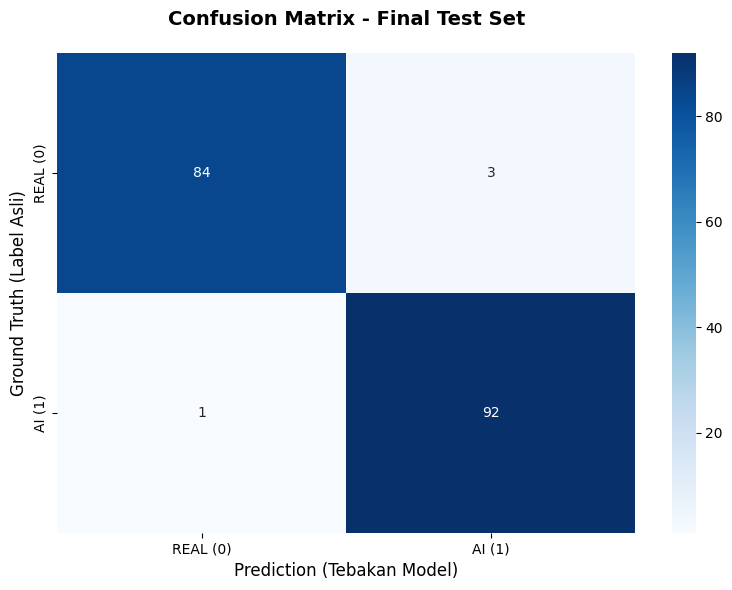

In [10]:
# Mengabaikan warning deprecation dari PyTorch agar output tetap bersih
warnings.filterwarnings("ignore", category=UserWarning)

def evaluate_final_model(model_path, test_loader, device):
    print("Memulai Evaluasi Final pada TEST SET...")
    print("-" * 50)
    
    # 1. Memuat Ulang Arsitektur dan Bobot Terbaik
    # Kita menggunakan fungsi build_convnext_binary_classifier yang sudah didefinisikan di tahap sebelumnya
    model = build_convnext_binary_classifier(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval() # Mengunci model ke mode evaluasi (mematikan Dropout dan BatchNorm tracking)
    
    all_preds = []
    all_labels = []
    
    # 2. Proses Inferensi (Pengujian)
    with torch.no_grad(): # Mematikan komputasi gradien untuk efisiensi memori dan kecepatan
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            
            # Konversi logits ke probabilitas menggunakan Sigmoid
            probs = torch.sigmoid(outputs)
            
            # Threshold 0.5: Jika > 0.5 maka AI (1), sebaliknya REAL (0)
            preds = (probs > 0.5).int().squeeze()
            
            # Mengumpulkan hasil ke CPU untuk dikalkulasi oleh scikit-learn
            # Memastikan format list kompatibel meskipun batch size bernilai 1
            if preds.ndim == 0:
                all_preds.append(preds.item())
                all_labels.append(labels.item())
            else:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # 3. Kalkulasi Metrik Evaluasi
    test_accuracy = accuracy_score(all_labels, all_preds)
    print(f"\n[HASIL] Akurasi Uji (Test Accuracy): {test_accuracy * 100:.2f}%\n")
    
    print("--- CLASSIFICATION REPORT ---")
    target_names = ['REAL (0)', 'AI (1)']
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))
    
    # 4. Visualisasi Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix - Final Test Set', pad=20, fontsize=14, fontweight='bold')
    plt.ylabel('Ground Truth (Label Asli)', fontsize=12)
    plt.xlabel('Prediction (Tebakan Model)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return all_labels, all_preds

# ==========================================
# EKSEKUSI EVALUASI
# ==========================================
if __name__ == "__main__":
    # Setup Perangkat
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Path model yang disimpan pada tahap pelatihan
    FINAL_MODEL_PATH = os.path.join(PROJECT_BASE_PATH, "model", "convnext_ai_detector.pth")
    
    # Asumsi: test_loader sudah tersedia di memori environment Anda
    # Eksekusi evaluasi
    true_labels, model_predictions = evaluate_final_model(FINAL_MODEL_PATH, test_loader, device)

## **Percobaan (Testing)**

Memuat arsitektur ConvNeXt-Tiny dan menginjeksi bobot final...
--------------------------------------------------
Memproses Gambar: Diego_Velazquez_26.jpg


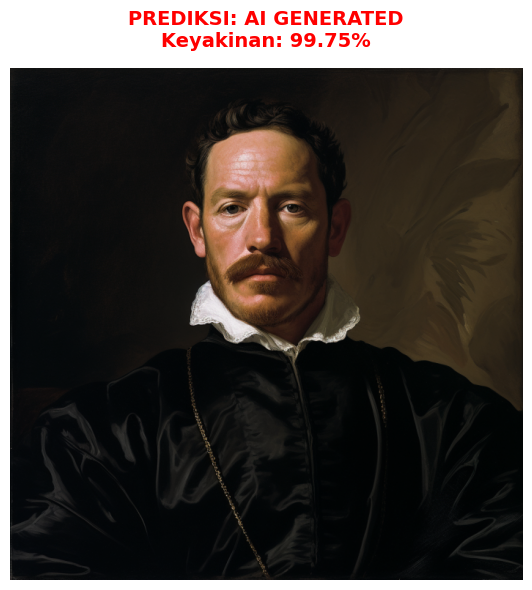

In [14]:
# Mengabaikan warning deprecation
warnings.filterwarnings("ignore", category=FutureWarning)

# ==========================================
# 1. KONFIGURASI PREPROCESSING (HARUS IDENTIK DENGAN TRAINING)
# ==========================================
IMAGE_SIZE = 320 # Harus persis sama dengan ukuran saat training terakhir

inference_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
    ToTensorV2()
])

# ==========================================
# 2. INISIALISASI ARSITEKTUR MODEL
# ==========================================
def load_trained_model(model_path, device):
    print("Memuat arsitektur ConvNeXt-Tiny dan menginjeksi bobot final...")
    
    # Inisialisasi arsitektur dasar
    model = models.convnext_tiny(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, 1)
    
    # Memuat bobot hasil pelatihan (menggunakan parameter keamanan yang direkomendasikan)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model = model.to(device)
    
    # KUNCI PENTING: Kunci model ke mode evaluasi
    model.eval()
    return model

# ==========================================
# 3. FUNGSI PREDIKSI DAN VISUALISASI UTAMA
# ==========================================
def predict_image(image_path, model, device):
    if not os.path.exists(image_path):
        print(f"ERROR: Gambar tidak ditemukan di path -> {image_path}")
        return
        
    print("-" * 50)
    print(f"Memproses Gambar: {os.path.basename(image_path)}")
        
    # Membaca gambar menggunakan teknik aman untuk OS Windows (Bypass Unicode issues)
    stream = open(image_path, "rb")
    bytes_array = bytearray(stream.read())
    numpyarray = np.asarray(bytes_array, dtype=np.uint8)
    image = cv2.imdecode(numpyarray, cv2.IMREAD_COLOR)
    
    if image is None:
        print("ERROR: File tidak dapat dirender sebagai gambar oleh OpenCV.")
        return
        
    # Simpan gambar asli (RGB) untuk keperluan visualisasi (plotting)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Terapkan transformasi (Resize & Normalisasi)
    transformed = inference_transform(image=image_rgb)
    image_tensor = transformed['image']
    
    # Tambahkan dimensi Batch
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Proses Inferensi
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()
        
    # Logika Klasifikasi (Threshold 0.5)
    if probability >= 0.5:
        prediction_label = "AI GENERATED"
        confidence = probability * 100
        color = "red"
    else:
        prediction_label = "REAL ARTWORK"
        confidence = (1.0 - probability) * 100
        color = "green"
        
    # --- MENAMPILKAN HASIL PREVIEW ---
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    
    title_text = f"PREDIKSI: {prediction_label}\nKeyakinan: {confidence:.2f}%"
    plt.title(title_text, color=color, fontweight='bold', fontsize=14, pad=15)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. FUNGSI PEMILIH GAMBAR ACAK (DYNAMIC FETCHING)
# ==========================================
def get_random_image_from_dir(directory_path):
    """Fungsi ini akan mengambil satu gambar secara acak dari folder yang diberikan."""
    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Direktori tidak ditemukan: {directory_path}")
        
    # Hanya mengambil ekstensi gambar
    valid_exts = {'.jpg', '.jpeg', '.png', '.webp'}
    all_files = [f for f in os.listdir(directory_path) if os.path.splitext(f)[1].lower() in valid_exts]
    
    if not all_files:
        raise ValueError(f"Tidak ada gambar valid di dalam folder {directory_path}")
        
    random_file = random.choice(all_files)
    return os.path.join(directory_path, random_file)

# ==========================================
# EKSEKUSI PENGUJIAN DUNIA NYATA
# ==========================================
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    FINAL_MODEL_PATH = os.path.join(PROJECT_BASE_PATH, "model", "convnext_ai_detector.pth")
    
    # 1. Setup Device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # 2. Muat Model ke dalam Memori
    ai_detector_model = load_trained_model(FINAL_MODEL_PATH, device)
    
    # 3. Definisikan Direktori Target Pengujian (jika ingin menguji gambar Ai atau bukan tinggal disesuaikan saja)
    TARGET_DIR = os.path.join(PROJECT_BASE_PATH, "data", "Midjourney", "art")
    
    try:
        # Mengambil file acak 
        TEST_IMAGE_PATH = get_random_image_from_dir(TARGET_DIR)
        
        # 4. Lakukan Prediksi
        predict_image(TEST_IMAGE_PATH, ai_detector_model, device)
        
    except Exception as e:
        print(f"Proses Pengujian Gagal: {e}")